In [1]:
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

In [4]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.drop("customerID", axis=1, inplace=True)

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(0, inplace=True)

In [11]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [12]:
df["Churn"].value_counts(normalize=True)


Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

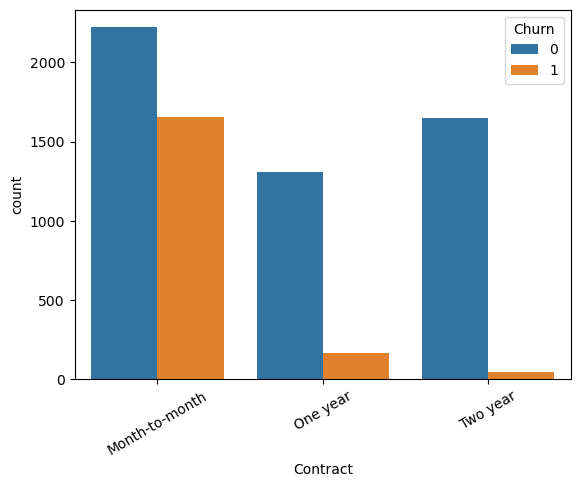

In [13]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=30)
plt.show()

In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [15]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [18]:
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8463870474500992


In [19]:
df["churn_probability"] = model.predict_proba(
    scaler.transform(X)
)[:, 1]

In [20]:
df["CLV"] = df["MonthlyCharges"] / df["churn_probability"]

In [21]:
df["offer_cost"] = 0.2 * df["MonthlyCharges"]

In [22]:
df["delta_churn"] = 0.3 * df["churn_probability"]

In [23]:
df["expected_revenue_saved"] = df["CLV"] * df["delta_churn"]

In [24]:
df["ROI"] = df["expected_revenue_saved"] - df["offer_cost"]

In [25]:
TOTAL_BUDGET = 500000  # example ₹5 lakh

In [26]:
target_df = df[df["ROI"] > 0].sort_values(by="ROI", ascending=False)

In [27]:
target_df["cumulative_cost"] = target_df["offer_cost"].cumsum()
final_targets = target_df[target_df["cumulative_cost"] <= TOTAL_BUDGET]

In [28]:
final_targets[[
    "tenure",
    "MonthlyCharges",
    "churn_probability",
    "CLV",
    "offer_cost",
    "expected_revenue_saved",
    "ROI"
]].head(700)

,tenure,MonthlyCharges,churn_probability,CLV,offer_cost,expected_revenue_saved,ROI
4586,72,118.75,0.044577,2663.906550,23.75,35.625,11.875
2115,71,118.65,0.077775,1525.563415,23.73,35.595,11.865
4804,61,118.60,0.164998,718.795581,23.72,35.580,11.860
3894,68,118.60,0.042744,2774.683746,23.72,35.580,11.860
5127,67,118.35,0.103032,1148.668923,23.67,35.505,11.835
...,...,...,...,...,...,...,...
2879,70,102.95,0.434876,236.734399,20.59,30.885,10.295
4211,24,102.95,0.646784,159.172227,20.59,30.885,10.295
5739,67,102.90,0.072743,1414.569936,20.58,30.870,10.290
617,66,102.85,0.203418,505.608154,20.57,30.855,10.285


In [53]:
final_targets.shape


(2665, 28)

In [54]:
final_targets.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2665 entries, 0 to 2664
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2665 non-null   object 
 1   SeniorCitizen           2665 non-null   int64  
 2   Partner                 2665 non-null   object 
 3   Dependents              2665 non-null   object 
 4   tenure                  2665 non-null   int64  
 5   PhoneService            2665 non-null   object 
 6   MultipleLines           2665 non-null   object 
 7   InternetService         2665 non-null   object 
 8   OnlineSecurity          2665 non-null   object 
 9   OnlineBackup            2665 non-null   object 
 10  DeviceProtection        2665 non-null   object 
 11  TechSupport             2665 non-null   object 
 12  StreamingTV             2665 non-null   object 
 13  StreamingMovies         2665 non-null   object 
 14  Contract                2665 non-null   

In [55]:
final_targets.head()
final_targets.tail()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,churn_probability,CLV,offer_cost,delta_churn,expected_revenue_saved,ROI,expected_lifetime,cumulative_cost
2660,Male,0,Yes,No,3,Yes,Yes,No,No internet service,No internet service,...,89.05,0,0.306985,76.876605,4.72,0.046048,7.080,2.360,3.257483,41055.44
2661,Male,0,Yes,No,1,No,No phone service,DSL,No,No,...,23.45,1,0.648320,36.170384,4.69,0.259328,7.035,2.345,1.542447,41060.13
2662,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,19.85,1,0.316253,62.766282,3.97,0.047438,5.955,1.985,3.162029,41064.10
2663,Male,0,No,No,2,Yes,No,No,No internet service,No internet service,...,31.20,0,0.307214,63.961969,3.93,0.046082,5.895,1.965,3.255062,41068.03
2664,Female,1,No,No,1,Yes,No,No,No internet service,No internet service,...,19.45,1,0.358339,54.278229,3.89,0.053751,5.835,1.945,2.790654,41071.92


In [56]:
print("Customers Targeted:", final_targets.shape[0])
print("Total Budget Used:", final_targets["offer_cost"].sum())
print("Total Expected Revenue Saved:", final_targets["expected_revenue_saved"].sum())
print("Net ROI:", final_targets["ROI"].sum())

Customers Targeted: 2665
Total Budget Used: 41071.920000000006
Total Expected Revenue Saved: 61607.87999999999
Net ROI: 20535.959999999995


In [57]:
##
df = df[df["churn_probability"] >= 0.3]


In [58]:
df["expected_lifetime"] = np.minimum(12, 1 / df["churn_probability"])
df["CLV"] = df["MonthlyCharges"] * df["expected_lifetime"]


In [59]:
df["delta_churn"] = np.where(
    df["churn_probability"] >= 0.5,
    0.4 * df["churn_probability"],   # high-risk → strong effect
    0.15 * df["churn_probability"]   # moderate-risk → weaker effect
)


In [60]:
TOTAL_BUDGET = 50000


In [61]:
profitable_customers = df[df["ROI"] > 0]


In [62]:
profitable_customers = profitable_customers.sort_values(
    by="ROI", ascending=False
)

In [63]:
profitable_customers["cumulative_cost"] = (
    profitable_customers["offer_cost"].cumsum()
)

final_targets = profitable_customers[
    profitable_customers["cumulative_cost"] <= TOTAL_BUDGET
]

In [64]:
rejected = df[~df.index.isin(final_targets.index)]


In [65]:
final_targets.shape[0]


2665

In [66]:
final_targets["offer_cost"].sum()


41071.920000000006

In [67]:
final_targets["expected_revenue_saved"].sum()


61607.87999999999

In [68]:
final_targets["expected_revenue_saved"].sum() - final_targets["offer_cost"].sum()


20535.959999999985

In [69]:
final_targets["churn_probability"].describe()


count    2665.000000
mean        0.543103
std         0.144723
min         0.300052
25%         0.418084
50%         0.547315
75%         0.663960
max         0.859032
Name: churn_probability, dtype: float64

In [70]:
final_targets["CLV"].describe()


count    2665.000000
mean      150.519515
std        57.822760
min        36.170384
25%       112.755341
50%       136.340082
75%       177.796273
max       372.774716
Name: CLV, dtype: float64

In [71]:
rejected_customers = df.loc[~df.index.isin(final_targets.index)]


In [72]:
rejected_customers["ROI"].describe()


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: ROI, dtype: float64

In [73]:
final_targets["churn_probability"].mean()


0.5431034800605845

In [74]:
final_targets["delta_churn"].mean()


0.17608714284334326

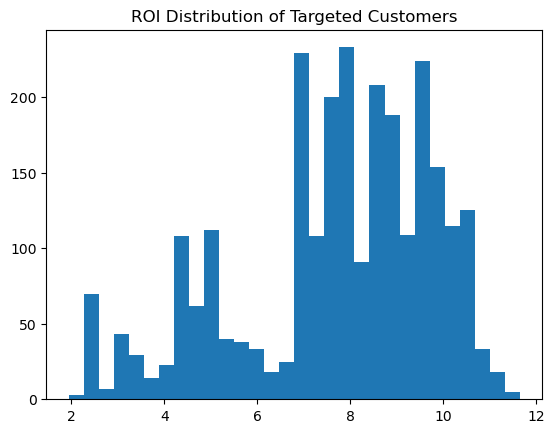

In [75]:
plt.hist(final_targets["ROI"], bins=30)
plt.title("ROI Distribution of Targeted Customers")
plt.show()


In [76]:
final_targets = final_targets.sort_values(by="ROI", ascending=False).reset_index(drop=True)


In [77]:
final_targets["cumulative_cost"] = final_targets["offer_cost"].cumsum()


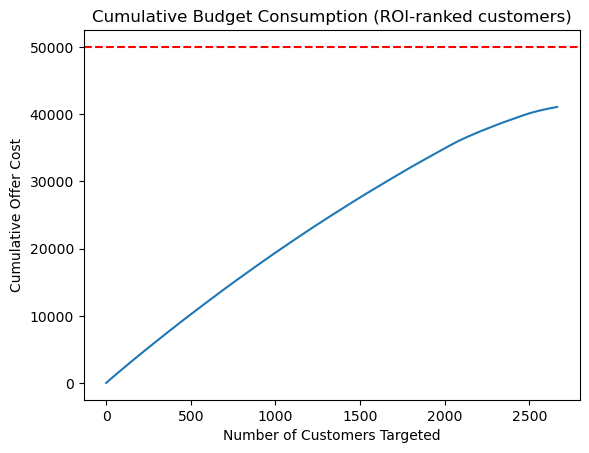

In [78]:
plt.figure()
plt.plot(final_targets["cumulative_cost"])
plt.axhline(TOTAL_BUDGET, linestyle="--", color="red")
plt.title("Cumulative Budget Consumption (ROI-ranked customers)")
plt.xlabel("Number of Customers Targeted")
plt.ylabel("Cumulative Offer Cost")
plt.show()


In [79]:
from sklearn.metrics import classification_report

y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1294
           1       0.66      0.55      0.60       467

    accuracy                           0.81      1761
   macro avg       0.75      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761

